# EvoHash — Baseline Evaluation

Runs all baseline attacks against each PHF and displays all primary and secondary metrics.

**Primary metrics:** ASR, Efficiency (ASR / L2), L2, Time  
**Secondary metrics:** LPIPS, Query Efficiency  

Set `N_PAIRS` to 100 for the full benchmark, or lower for a quick test.

In [1]:
import sys
from pathlib import Path

# Make sure we can import evohash from the repo root
PROJECT_ROOT = Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import importlib.util
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from evohash.dataset import load_image_pairs
from evohash.evaluation import (
    compute_asr,
    compute_efficiency,
    compute_lpips,
    compute_mean_l2,
    compute_mean_queries,
    image_to_array,
)
from evohash.phf import get_phf

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

DATA_DIR = PROJECT_ROOT / "data" / "imagenet_val"

# ── Config ────────────────────────────────────────────────────────────────────
N_PAIRS  = 20    # set to 100 for the full benchmark
PHFS     = ["phash", "pdq"]   # add "neuralhash" if on macOS
print(f"N_PAIRS={N_PAIRS}, PHFs={PHFS}")

N_PAIRS=20, PHFs=['phash', 'pdq']


In [3]:
def load_attack(path: Path):
    """Dynamically load entrypoint() from a .py file."""
    spec = importlib.util.spec_from_file_location("attack", path)
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod.entrypoint


def evaluate_one(attack_fn, phf_name: str, n_pairs: int) -> dict:
    """Run one attack and return all metrics."""
    phf = get_phf(phf_name)
    pairs = load_image_pairs(DATA_DIR, n_pairs=n_pairs)
    sources = [p[0] for p in pairs]
    targets = [p[1] for p in pairs]
    target_hashes = [phf.compute(img) for img in targets]

    context = {
        "hash_fn": phf,
        "threshold": phf.threshold,
        "source_images": sources,
        "target_hashes": target_hashes,
        "target_images": targets,
    }

    t0 = time.time()
    result = attack_fn(context)
    elapsed = time.time() - t0

    attacked_pil = result.get("attacked_images", [])
    per_image    = result.get("metrics", [])

    originals     = [image_to_array(img) for img in sources]
    attacked_arrs = [image_to_array(img) for img in attacked_pil]

    asr          = compute_asr(per_image)
    mean_l2      = compute_mean_l2(originals, attacked_arrs)
    efficiency   = compute_efficiency(asr, mean_l2)
    mean_queries = compute_mean_queries(per_image)
    lpips_score  = compute_lpips(originals, attacked_arrs)
    time_per     = elapsed / max(len(sources), 1)

    return {
        "asr":          asr,
        "l2":           mean_l2,
        "efficiency":   efficiency,
        "queries":      mean_queries,
        "lpips":        lpips_score,
        "time_s":       time_per,
    }

## Run all baselines

In [4]:
rows = []

for phf_name in PHFS:
    seeds_dir = PROJECT_ROOT / "problems" / phf_name / "initial_programs"
    programs  = sorted(seeds_dir.glob("*.py"))

    print(f"\n{'='*60}")
    print(f"  PHF: {phf_name.upper()}  ({len(programs)} baselines)")
    print(f"{'='*60}")

    for prog_path in programs:
        if prog_path.stem == "placeholder":
            continue
        print(f"  [{phf_name}] {prog_path.stem} ...", end=" ", flush=True)
        try:
            fn = load_attack(prog_path)
            m  = evaluate_one(fn, phf_name, N_PAIRS)
            rows.append({"attack": prog_path.stem, "phf": phf_name, **m})
            print(f"ASR={m['asr']:.2f}  L2={m['l2']:.2f}  eff={m['efficiency']:.4f}")
        except Exception as e:
            print(f"ERROR: {e}")

df = pd.DataFrame(rows)
print(f"\nDone. {len(df)} results collected.")


  PHF: PHASH  (10 baselines)
  [phash] atkscopes_attack ... Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /Users/amir/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:32<00:00, 7.57MB/s] 


ASR=0.00  L2=0.05  eff=0.0000
  [phash] hsja_attack ... ASR=1.00  L2=50.57  eff=0.0198
  [phash] nes_attack ... ASR=0.00  L2=0.25  eff=0.0000
  [phash] nes_hsja_attack ... ASR=1.00  L2=42.50  eff=0.0235
  [phash] prokos_attack ... ASR=0.00  L2=0.11  eff=0.0000
  [phash] random_noise ... ASR=0.00  L2=2.79  eff=0.0000
  [phash] simba_attack ... ASR=0.00  L2=0.06  eff=0.0000
  [phash] simba_hsja_attack ... ASR=1.00  L2=47.21  eff=0.0212
  [phash] zo_signsgd_attack ... ASR=0.00  L2=0.62  eff=0.0000
  [phash] zo_signsgd_hsja_attack ... ASR=1.00  L2=50.61  eff=0.0198

  PHF: PDQ  (10 baselines)
  [pdq] atkscopes_attack ... ASR=0.00  L2=0.23  eff=0.0000
  [pdq] hsja_attack ... ASR=1.00  L2=22.16  eff=0.0451
  [pdq] nes_attack ... ASR=0.00  L2=1.10  eff=0.0000
  [pdq] nes_hsja_attack ... ASR=1.00  L2=19.47  eff=0.0514
  [pdq] prokos_attack ... ASR=0.00  L2=0.67  eff=0.0000
  [pdq] random_noise ... ASR=0.00  L2=9.35  eff=0.0000
  [pdq] simba_attack ... ASR=0.00  L2=0.01  eff=0.0000
  [pdq] simb

## Results table

In [5]:
def fmt(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    d["ASR"]        = d["asr"].map("{:.3f}".format)
    d["L2"]         = d["l2"].map("{:.2f}".format)
    d["Efficiency"] = d["efficiency"].map("{:.4f}".format)
    d["Queries"]    = d["queries"].map("{:.0f}".format)
    d["LPIPS"]      = d["lpips"].apply(lambda v: "{:.4f}".format(v) if not np.isnan(v) else "N/A")
    d["Time (s)"]   = d["time_s"].map("{:.2f}".format)
    return d[["attack", "phf", "ASR", "L2", "Efficiency", "Queries", "LPIPS", "Time (s)"]]

for phf_name in PHFS:
    sub = df[df["phf"] == phf_name].sort_values("efficiency", ascending=False)
    print(f"\n── {phf_name.upper()} ──")
    display(fmt(sub).set_index("attack").drop(columns="phf"))


── PHASH ──


,ASR,L2,Efficiency,Queries,LPIPS,Time (s)
attack,,,,,,
nes_hsja_attack,1.000,42.50,0.0235,3353,0.4600,2.95
simba_hsja_attack,1.000,47.21,0.0212,1116,0.4986,0.90
hsja_attack,1.000,50.57,0.0198,1612,0.4635,2.32
zo_signsgd_hsja_attack,1.000,50.61,0.0198,3962,0.5133,3.55
atkscopes_attack,0.000,0.05,0.0000,61673,0.0000,9.92
nes_attack,0.000,0.25,0.0000,6151,0.0001,5.20
prokos_attack,0.000,0.11,0.0000,6121,0.0000,7.15
random_noise,0.000,2.79,0.0000,201,0.0390,0.32
simba_attack,0.000,0.06,0.0000,4001,0.0000,12.51



── PDQ ──


,ASR,L2,Efficiency,Queries,LPIPS,Time (s)
attack,,,,,,
nes_hsja_attack,1.000,19.47,0.0514,3326,0.2024,4.16
hsja_attack,1.000,22.16,0.0451,1615,0.1944,2.41
zo_signsgd_hsja_attack,1.000,22.70,0.0441,3966,0.2500,5.60
simba_hsja_attack,1.000,28.80,0.0347,1120,0.2914,1.57
atkscopes_attack,0.000,0.23,0.0000,61673,0.0000,27.38
nes_attack,0.000,1.10,0.0000,12201,0.0011,14.67
prokos_attack,0.000,0.67,0.0000,6121,0.0004,8.44
random_noise,0.000,9.35,0.0000,201,0.1245,0.49
simba_attack,0.000,0.01,0.0000,601,0.0000,0.41


## Efficiency comparison (all PHFs)

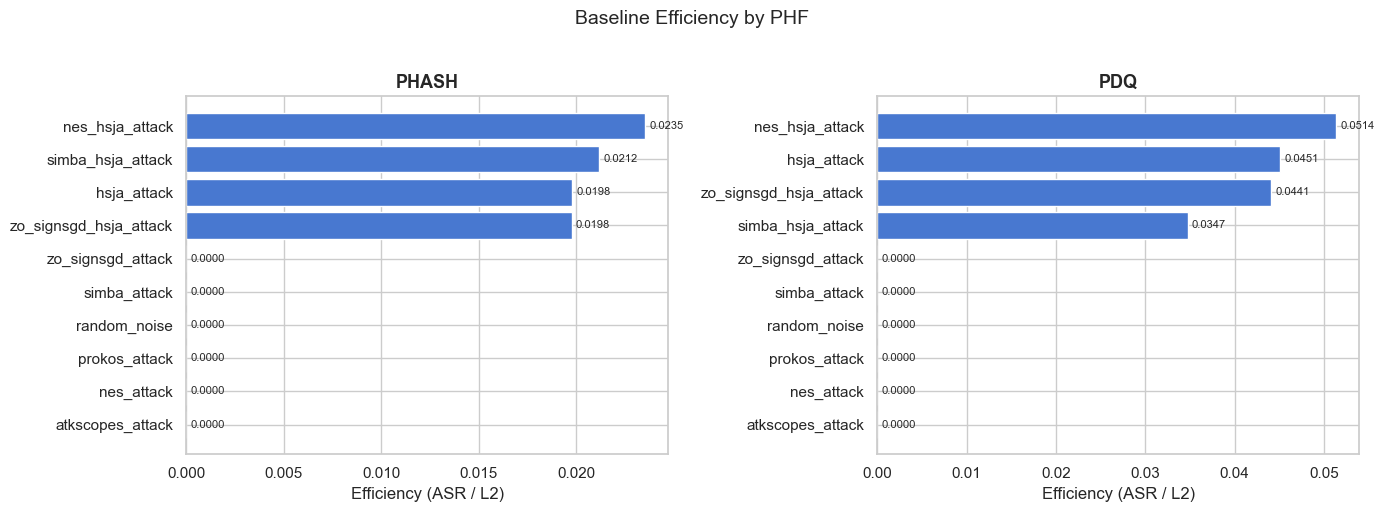

In [6]:
fig, axes = plt.subplots(1, len(PHFS), figsize=(7 * len(PHFS), 5), sharey=False)
if len(PHFS) == 1:
    axes = [axes]

for ax, phf_name in zip(axes, PHFS):
    sub = df[df["phf"] == phf_name].sort_values("efficiency", ascending=True)
    bars = ax.barh(sub["attack"], sub["efficiency"], color=sns.color_palette()[0])
    ax.set_title(phf_name.upper(), fontsize=13, fontweight="bold")
    ax.set_xlabel("Efficiency (ASR / L2)")
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)

plt.suptitle("Baseline Efficiency by PHF", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## ASR vs L2 scatter

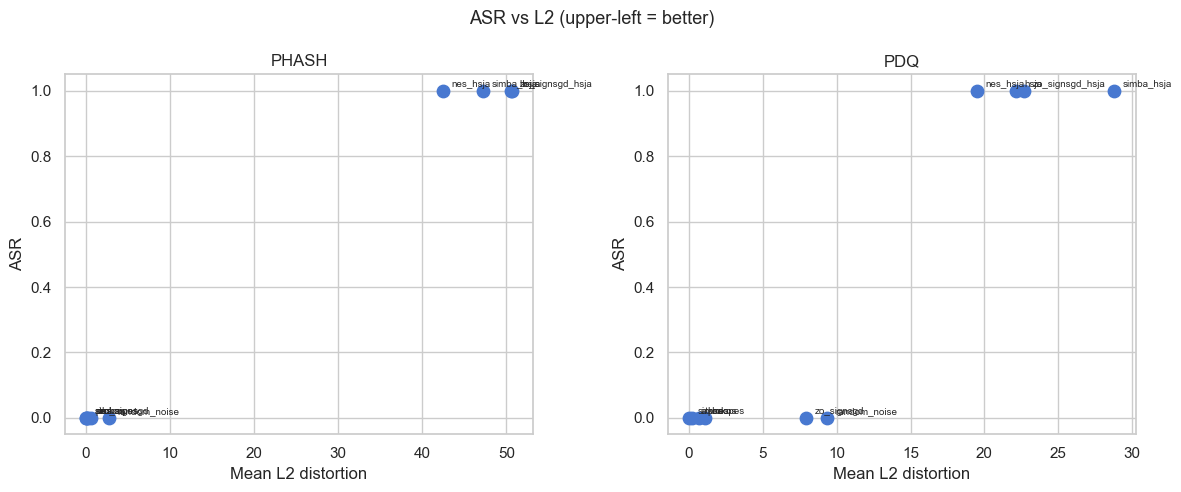

In [7]:
fig, axes = plt.subplots(1, len(PHFS), figsize=(6 * len(PHFS), 5))
if len(PHFS) == 1:
    axes = [axes]

for ax, phf_name in zip(axes, PHFS):
    sub = df[df["phf"] == phf_name]
    sc  = ax.scatter(sub["l2"], sub["asr"], s=80, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(
            row["attack"].replace("_attack", ""),
            (row["l2"], row["asr"]),
            textcoords="offset points", xytext=(6, 3), fontsize=7,
        )
    ax.set_xlabel("Mean L2 distortion")
    ax.set_ylabel("ASR")
    ax.set_title(phf_name.upper())
    ax.set_ylim(-0.05, 1.05)

plt.suptitle("ASR vs L2 (upper-left = better)", fontsize=13)
plt.tight_layout()
plt.show()

## Heatmap: all metrics

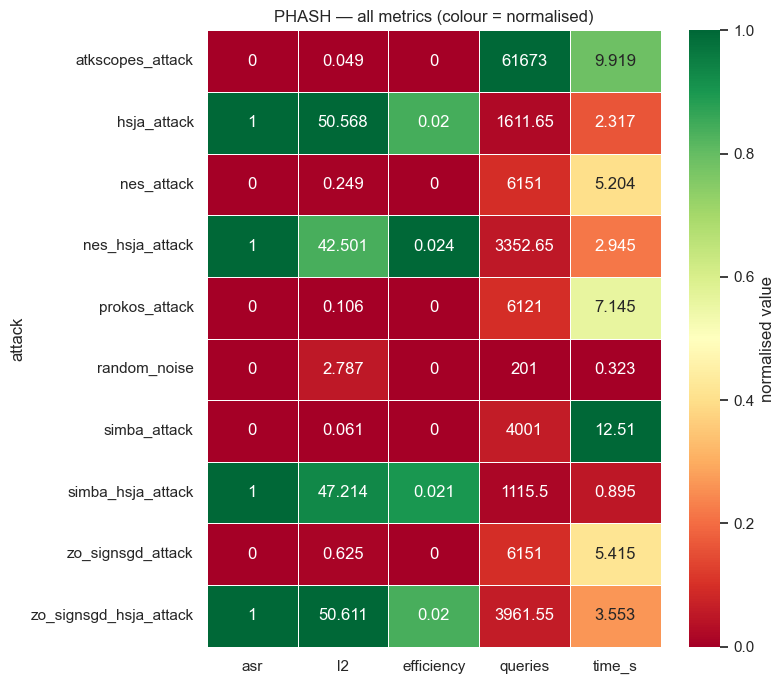

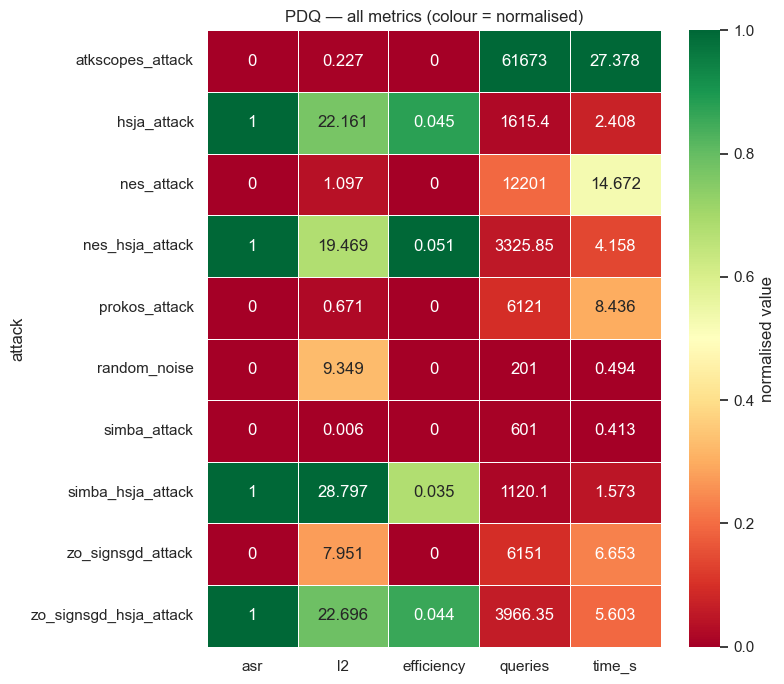

In [8]:
for phf_name in PHFS:
    sub = df[df["phf"] == phf_name].set_index("attack")
    metrics_cols = ["asr", "l2", "efficiency", "queries", "time_s"]
    heat = sub[metrics_cols].copy()

    # Normalise each column to [0, 1] for visual comparison
    heat_norm = (heat - heat.min()) / (heat.max() - heat.min() + 1e-9)

    fig, ax = plt.subplots(figsize=(8, 0.5 * len(heat) + 2))
    sns.heatmap(
        heat_norm, annot=heat.round(3), fmt="g",
        cmap="RdYlGn", linewidths=0.5, ax=ax,
        cbar_kws={"label": "normalised value"},
    )
    ax.set_title(f"{phf_name.upper()} — all metrics (colour = normalised)", fontsize=12)
    plt.tight_layout()
    plt.show()

## Save to CSV

In [9]:
out_path = PROJECT_ROOT / "results_baselines.csv"
df.to_csv(out_path, index=False)
print(f"Saved → {out_path}")
df

Saved → /Users/amir/skoltech_courses/trustworthy/evohash/results_baselines.csv


,attack,phf,asr,l2,efficiency,queries,lpips,time_s
0,atkscopes_attack,phash,0.0,0.049224,0.000000,61673.00,6.920798e-06,9.919228
1,hsja_attack,phash,1.0,50.567851,0.019775,1611.65,4.634567e-01,2.317497
2,nes_attack,phash,0.0,0.249454,0.000000,6151.00,6.473791e-05,5.203654
3,nes_hsja_attack,phash,1.0,42.501090,0.023529,3352.65,4.600442e-01,2.945035
4,prokos_attack,phash,0.0,0.105916,0.000000,6121.00,2.215164e-05,7.145102
5,random_noise,phash,0.0,2.787143,0.000000,201.00,3.901145e-02,0.322679
6,simba_attack,phash,0.0,0.061233,0.000000,4001.00,1.907501e-05,12.510345
7,simba_hsja_attack,phash,1.0,47.213923,0.021180,1115.50,4.986405e-01,0.895161
8,zo_signsgd_attack,phash,0.0,0.624543,0.000000,6151.00,3.685308e-03,5.415340
9,zo_signsgd_hsja_attack,phash,1.0,50.610946,0.019759,3961.55,5.133492e-01,3.552852
